## Project Introduction
This project is a **linear regression model** to predict diamond prices based on their physical and qualitative characteristics. This project was done as an exercise for the first session of the Machine Learning course.

## Objective
Predict the price of a diamond using features such as:
- Carat weight
- Cut quality
- Color
- Clarity
- Physical dimensions (x, y, z)

## Steps completed

### 1. Exploratory Data Analysis (EDA)
- Examining the distribution of data and identifying missing data
- Correlation matrix analysis to identify key features
- Visualizing the relationship between features and price

### 2. Data preprocessing
- **Ordinal Encoding:** Converting qualitative features to numbers while preserving the order
- Cut: Fair → Ideal (0 to 4)
- Color: J → D (0 to 6)
- Clarity: I1 → IF (0 to 7)
- **Standardization:** Using StandardScaler
- **Data partitioning:** 80% training, 20% testing

### 3. Model training
- Using **Linear Regression** from the Scikit-learn library

### 4. Model Evaluation
- **R² Score:** 0.937 (93.7% accuracy in explaining price changes)
- **MAE:** $671.58 (Mean Absolute Error)
- **RMSE:** $1006.60 (Root Mean Square Error)


## Results and Insights

### Key Findings from the Correlation Matrix:
1. **Carat Weight** is the strongest predictor of price with a correlation coefficient of **0.92**.
2. **Dimensions (x, y, z)** have a very high correlation with weight (**0.98**), so only weight was used to avoid multicollinearity.
3. **Depth** and **Table** have a negligible impact on price (correlation < 0.2).
4. **Clarity** and **Color** have a moderate and inverse impact on price.

### Model Strengths:
- Simplicity and high interpretability
- Good performance with R² = 0.937
- Suitable as a baseline for more complex models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error



In [2]:
url = 'https://raw.githubusercontent.com/abhijitpaul0212/DataSets/main/gemstone.csv'

df = pd.read_csv(url)
df.head(10)

##وزن (carat)، کیفیت برش (cut)، رنگ (color)، شفافیت (clarity)، (depth, table) درصدهای مربوط به عمق و سطح روی سنگ

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453
5,5,1.51,Very Good,J,SI1,62.8,58.0,7.34,7.29,4.59,7506
6,6,0.74,Ideal,E,VS2,61.8,57.0,5.76,5.79,3.57,3229
7,7,1.34,Premium,G,SI2,62.5,57.0,7.00,7.05,4.38,6224
8,8,0.30,Ideal,F,IF,62.0,56.0,4.35,4.37,2.70,886
9,9,0.30,Good,J,VS1,63.6,57.0,4.26,4.28,2.72,421


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


In [4]:
df.describe()

,id,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,55879.856166,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.000000,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,48393.000000,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,96786.000000,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,145179.000000,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,193572.000000,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


In [10]:
X = df.drop('price', axis=1)
y = df['price']

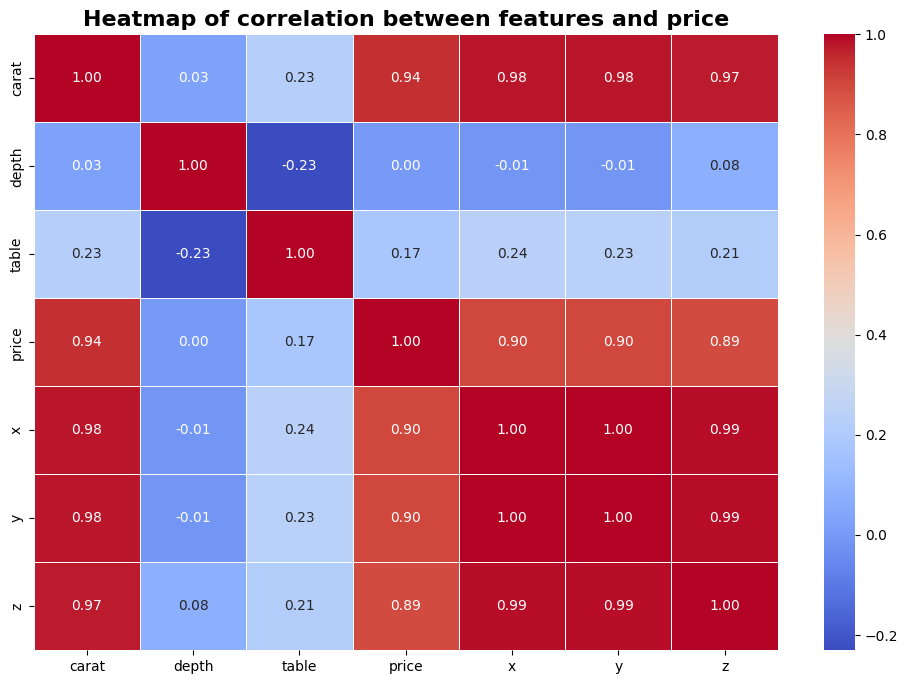

In [12]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']].corr()

# heatmap

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmap of correlation between features and price', fontsize=16, fontweight='bold')
plt.show()

Text(0, 0.5, ' price')

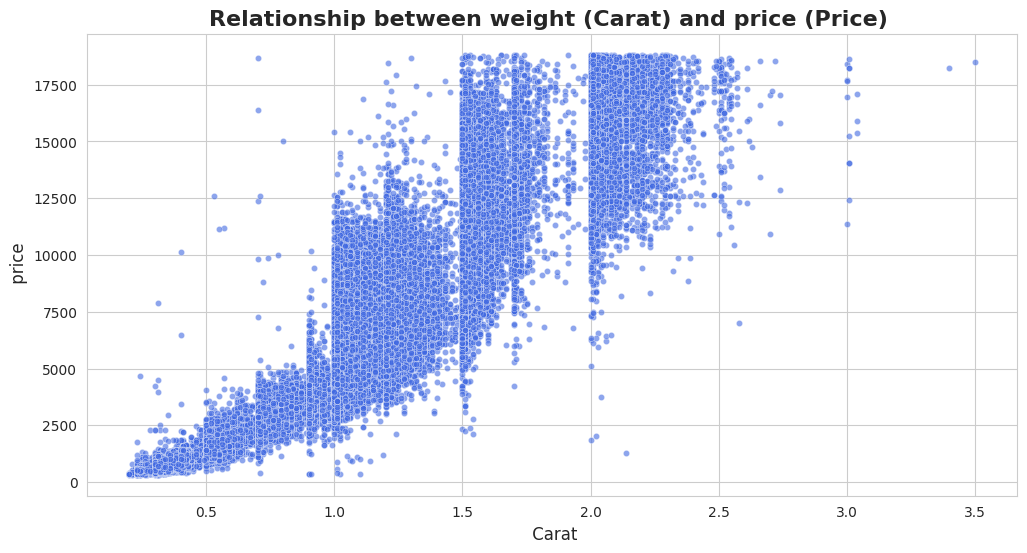

In [13]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


sns.scatterplot(data=df, x='carat', y='price', alpha=0.6, color='royalblue', s=20)

plt.title('Relationship between weight (Carat) and price (Price) ', fontsize=16, fontweight='bold')
plt.xlabel(' Carat', fontsize=12)
plt.ylabel(' price', fontsize=12)

/tmp/ipykernel_1964/2409967015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cut', y='price', palette='viridis', order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])


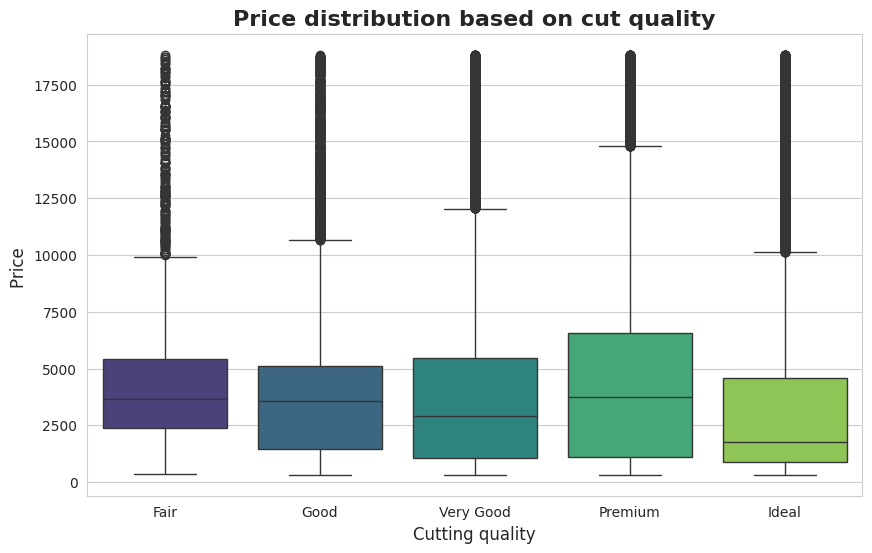

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='cut', y='price', palette='viridis', order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])

plt.title('Price distribution based on cut quality', fontsize=16, fontweight='bold')
plt.xlabel('Cutting quality', fontsize=12)
plt.ylabel('Price ', fontsize=12)
plt.show()

In [15]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # از بدترین به بهترین
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

ordinal_encoder = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order])



In [16]:
X[['cut', 'color', 'clarity']] = ordinal_encoder.fit_transform(
    X[['cut', 'color', 'clarity']])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

In [22]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\n Importance of features ")
print(feature_importance)


 Importance of features 
   feature  coefficient
1    carat  6421.428635
7        x -1772.203606
4  clarity   652.416433
3    color   463.947651
8        y  -409.913240
5    depth  -129.822479
9        z   -81.595433
2      cut    70.263487
6    table   -68.943586
0       id     0.897262


In [23]:
y_pred= model.predict(X_test_scaled)

In [24]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"r2_score: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

r2_score: 0.9372974084689308
Mean Absolute Error: 671.5837002410251
Root Mean Squared Error: 1006.6018456121125


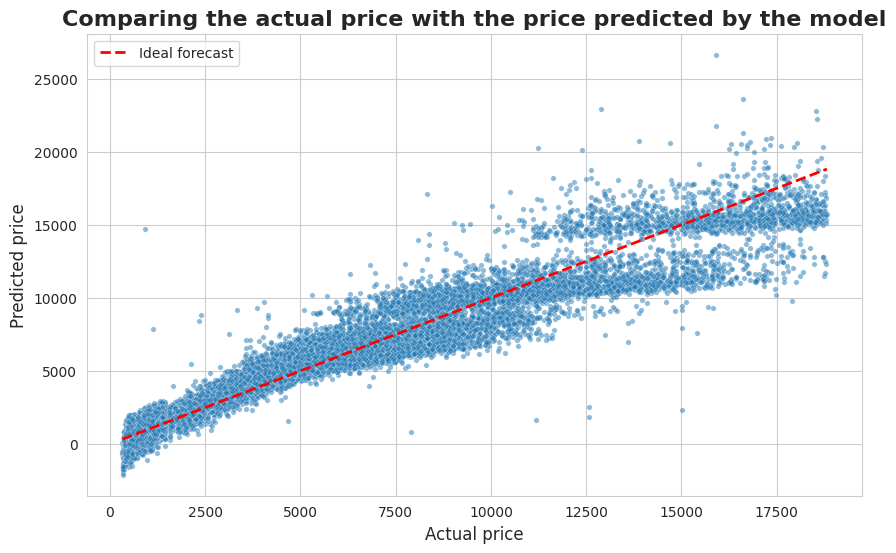

In [21]:

results = pd.DataFrame({
    'Real Price': y_test,
    'Predicted Price': y_pred
})
plt.figure(figsize=(10, 6))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         linestyle='--', color='red', linewidth=2, label='Ideal forecast')

sns.scatterplot(data=results, x='Real Price', y='Predicted Price', alpha=0.5, s=15)

plt.title('Comparing the actual price with the price predicted by the model', fontsize=16, fontweight='bold')
plt.xlabel('Actual price', fontsize=12)
plt.ylabel('Predicted price', fontsize=12)
plt.legend()
plt.show()